<h1>Sampling</h1>

Sampling is the process of selecting a statistical subset (a sample) from a large group (the population) to estimate characterstics of the entire group. Because analyzing an entire population is often computationally impossible or economically unfeasible, we rely on samples.

<h1>Resampling</h1>

Resampling is the process of repeatedly drawing samples from you existing, orginal sample to assess the variability of a statistics or model.

<h1>Why The matter in ML</h1>

- Sampling: Ensures the data your model learns from accurately represents the realworld. Poor sampling leads to bias.
- Resampling: Ensures your model's performance metrics are relibel. Poor resampling leads to false confidence(overfitting).

<h1>Terminologies</h1>

- Population(N): The complete set of all possible observations
- Sample(n): A subset of N used for training and testing
- Feature(X) and Target(y): In supervised learning, X are independent variables; y is the dependent variable we predict
- Distribution: How the data points are spread across different values(eg: Normal/Gaussian distribution)
- Bias: The error introduced by approximating a realworld problem, High Bias = Underfitting
- Variance: The error introduced by the model's sensitivity to small flactuations in the training set. High variance = overfitting
- Generallization: A model's ability to perform well on unseen data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

population_size = 10000

ages = np.random.normal(loc=45,scale=15,size=population_size)
ages = np.clip(ages,18,90)

incomes = 30000 + (ages * 1000) + np.random.normal(0,15000,population_size)

p_df = pd.DataFrame({'Age':ages,'Income':incomes})

p_df.head(20)

,Age,Income
0,52.450712,72273.291338
1,42.926035,68343.543537
2,54.715328,75754.612156
3,67.845448,99501.718550
4,41.487699,89445.377351
5,41.487946,59922.313289
6,68.688192,113700.499699
7,56.511521,74786.439852
8,37.957884,55243.476024
9,53.138401,95417.319929


In [6]:
sample_df = p_df.sample(n=200,random_state=42)

In [7]:
sample_df.head(20)

,Age,Income
6252,84.568226,118277.576278
4684,29.444009,48235.681413
1731,39.760248,106446.791595
4742,45.024285,82268.234648
4521,61.114995,93419.732011
6340,31.111651,58888.812086
576,48.534218,75737.672134
5202,47.241841,57889.330128
6363,55.248186,48927.489782
439,44.166785,64276.922495


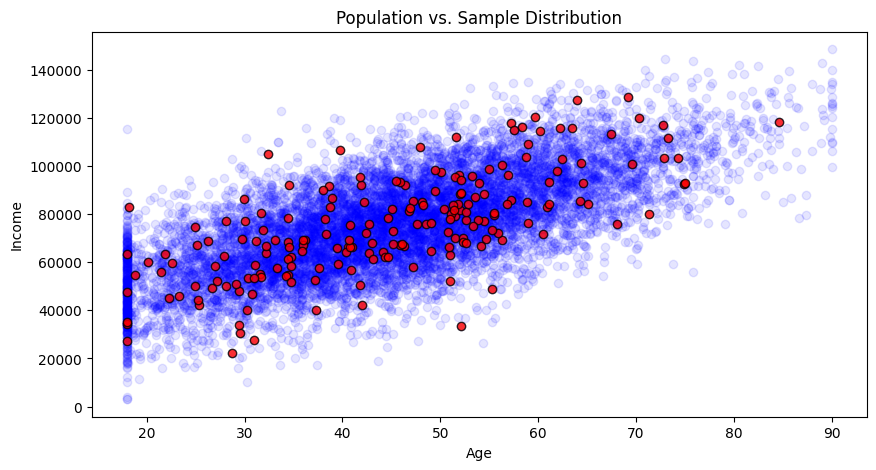

In [8]:
plt.figure(figsize=(10,5))
plt.scatter(p_df['Age'],p_df['Income'],alpha=0.1,label='population 10000',color='blue')
plt.scatter(sample_df['Age'],sample_df['Income'],alpha=0.8,label='sample 200',color='red',edgecolor='black')
plt.title("Population vs. Sample Distribution")
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

<h2>Types of sampling</h2>

- Simple Sampling
- Systematic Sampling
- Stratified Sampling

<h2>Simple sampling</h2>

Every item has an equal chance of selection

Adv: Highly unbiased, If N is homogeneous.
DisAdv: Can completely miss minority groups by random chance.

<h2>Systematic Sampling</h2>

Selecting every k-th element from a randomized list.


Step size : k = N/n

In [9]:
production_line = np.arange(0,100)

k = 10

start_index = 3

systematic_sample = production_line[start_index::k]

systematic_sample

array([ 3, 13, 23, 33, 43, 53, 63, 73, 83, 93])

<h2>Stratified Sampling</h2>

Dividing the population into homogeneous subgroups (strata) and taking a random sample from each stratum proportional to its size.

Why used: To ensure minority classes are properly represented.

Adv: Reduces sampling variance: ensures minority representation
DisAdv: Requrie Prior knowledge of the strata.

In [15]:
health_status = ['Healthy']*900 + ['Sick']*100

df_health = pd.DataFrame({'PiD': np.arange(1000),'Status':health_status})

df_health

,PiD,Status
0,0,Healthy
1,1,Healthy
2,2,Healthy
3,3,Healthy
4,4,Healthy
...,...,...
995,995,Sick
996,996,Sick
997,997,Sick
998,998,Sick


In [11]:
sample_size=100

In [21]:
sample_df = (
df_health.groupby('Status',group_keys=False)
.apply(lambda x:x.sample(
    int(np.rint(sample_size*len(x)/len(df_health)))
    ),include_groups=True)
    )

sample_df

ValueError: include_groups=True is no longer allowed.

In [24]:
df_health.groupby('Status',group_keys=False).sample(frac=0.1)

,PiD,Status
465,465,Healthy
763,763,Healthy
284,284,Healthy
64,64,Healthy
743,743,Healthy
...,...,...
911,911,Sick
973,973,Sick
925,925,Sick
942,942,Sick


In [25]:
df_health.groupby('Status',group_keys=False).sample(frac=0.1)['Status'].value_counts()

Status
Healthy    90
Sick       10
Name: count, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split


X_train,X_test,y_train,y_test = train_test_split(df_health['PiD'],df_health['Status'],test_size=0.2,stratify=df_health['Status'])

In [33]:
y_train.value_counts()

Status
Healthy    720
Sick        80
Name: count, dtype: int64

In [28]:
y_test.value_counts()

Status
Healthy    180
Sick        20
Name: count, dtype: int64